In [91]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [122]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/groceries.csv"
df = pd.read_csv(file_path)

transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
transactions

[['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product'],
 ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner'],
 ['rolls/buns'],
 ['other vegetables',
  'UHT-milk',
  'rolls/buns',
  'bottled beer',
  'liquor (appetizer)'],
 ['pot plants'],
 ['whole milk', 'cereals'],
 ['tropical fruit',
  'other vegetables',
  'white bread',
  'bottled water',
  'chocolate'],
 ['citrus fruit',
  'tropical fruit',
  'whole milk',
  'butter',
  'curd',
  'yogurt',
  'flour',
  'bottled water',
  'dishes'],
 ['beef'],
 ['frankfurter', 'rolls/buns', 'soda'],
 ['chicken', 'tropical fruit'],
 ['butter', 'sugar', 'fruit/vegetable juice', 'newspapers'],
 ['fruit/vegetable juice'],
 ['packaged fruit/vegetables'],
 ['chocolate'],
 ['specialty bar'],
 ['other vegetables'],
 ['butter milk', 'pastry'],
 ['whole milk'],
 ['tropical fruit',
  'cream cheese ',


In [72]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)

In [73]:
te_array

array([[False, False, False, ..., False,  True, False],
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       ...,
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [74]:
df = pd.DataFrame(te_array, columns = te.columns_)
df

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9830,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [75]:
freq_items = apriori(df, min_support = 0.02, use_colnames = True)
freq_items

,support,itemsets
0,0.033455,(UHT-milk)
1,0.052471,(beef)
2,0.033252,(berries)
3,0.026032,(beverages)
4,0.080537,(bottled beer)
...,...,...
117,0.032235,"(whole milk, whipped/sour cream)"
118,0.020744,"(yogurt, whipped/sour cream)"
119,0.056030,"(yogurt, whole milk)"
120,0.023185,"(root vegetables, whole milk, other vegetables)"


In [80]:
rules = association_rules(freq_items, metric = "confidence", min_threshold = 0.3)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(whole milk),0.052471,0.255542,0.021253,0.405039,1.585018,1.0,0.007844,1.251271,0.389532,0.074113,0.200813,0.244103
1,(bottled water),(whole milk),0.110535,0.255542,0.034371,0.310948,1.216816,1.0,0.006124,1.080408,0.200326,0.103617,0.074424,0.222724
2,(brown bread),(whole milk),0.064877,0.255542,0.025219,0.388715,1.521138,1.0,0.008640,1.217857,0.366366,0.085429,0.178885,0.243701
3,(butter),(other vegetables),0.055420,0.193512,0.020033,0.361468,1.867932,1.0,0.009308,1.263034,0.491910,0.087517,0.208256,0.232494
4,(butter),(whole milk),0.055420,0.255542,0.027557,0.497248,1.945855,1.0,0.013395,1.480765,0.514607,0.097237,0.324673,0.302543
5,(citrus fruit),(other vegetables),0.082672,0.193512,0.028879,0.349323,1.805175,1.0,0.012881,1.239460,0.486235,0.116776,0.193197,0.249281
6,(citrus fruit),(whole milk),0.082672,0.255542,0.030506,0.369004,1.444004,1.0,0.009380,1.179814,0.335192,0.099141,0.152408,0.244191
7,(curd),(whole milk),0.053285,0.255542,0.026134,0.490458,1.919285,1.0,0.012517,1.461034,0.505931,0.092446,0.315553,0.296363
8,(domestic eggs),(other vegetables),0.063453,0.193512,0.022270,0.350962,1.813639,1.0,0.009991,1.242588,0.479018,0.094887,0.195228,0.233021
9,(domestic eggs),(whole milk),0.063453,0.255542,0.029998,0.472756,1.850015,1.0,0.013783,1.411981,0.490593,0.103800,0.291775,0.295073


# **LINE PLOT FOR ASSOCIATION RULE METRICS**

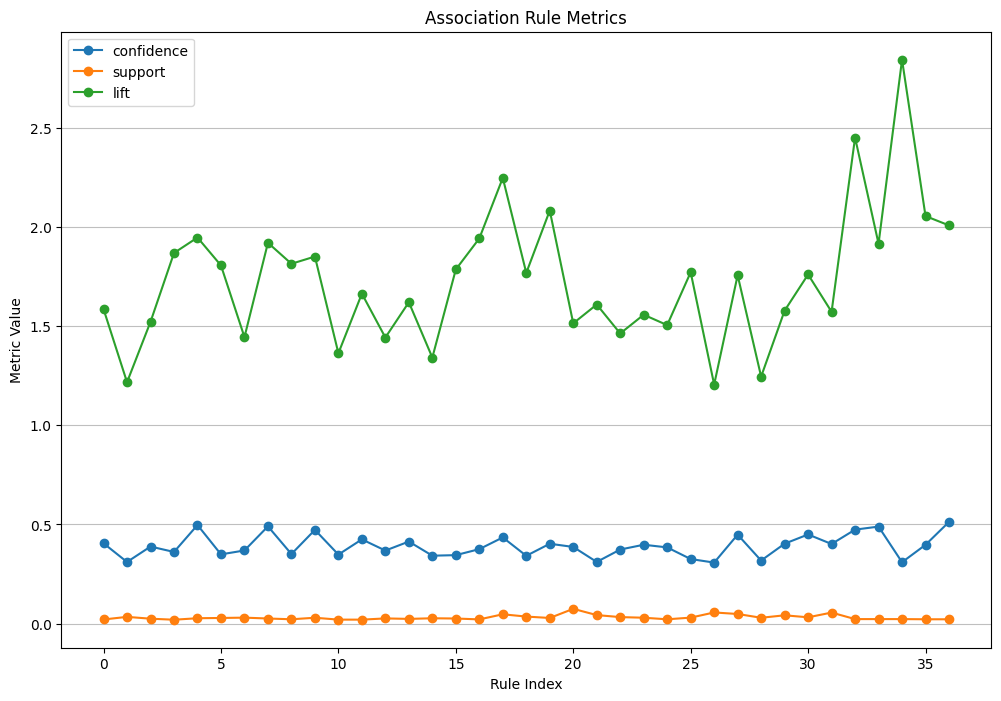

In [81]:
plt.figure(figsize = (12,8))
plt.plot(rules.index, rules[["confidence","support","lift"]],label = ["confidence","support","lift"], marker = "o")
plt.title("Association Rule Metrics")
plt.xlabel("Rule Index")
plt.ylabel("Metric Value")

plt.legend()
plt.grid(True, axis = "y", alpha = 0.8)
plt.show()

# **BOXPLOT FOR ASSOCIATION RULE METRICS**

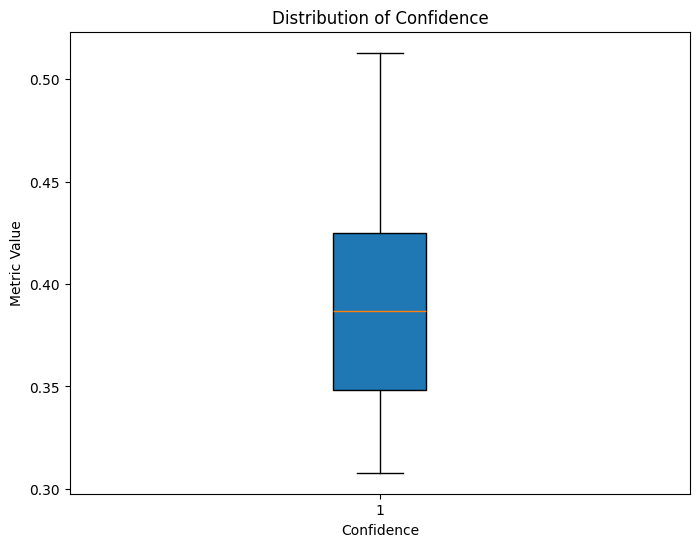

In [98]:
plt.figure(figsize = (8,6))
plt.boxplot(rules["confidence"], label = "Confidence", patch_artist=True)
plt.title("Distribution of Confidence")
plt.xlabel("Confidence")
plt.ylabel("Metric Value")

plt.show()

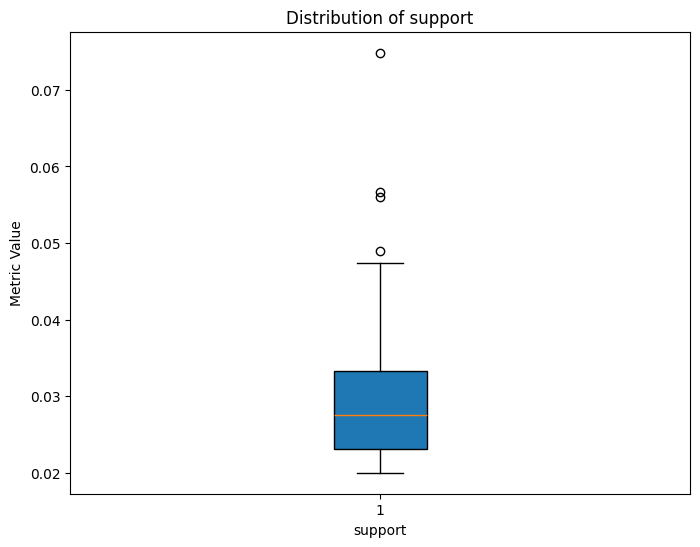

In [99]:
plt.figure(figsize = (8,6))
plt.boxplot(rules["support"], label = "Support", patch_artist=True)
plt.title("Distribution of support")
plt.xlabel("support")
plt.ylabel("Metric Value")

plt.show()

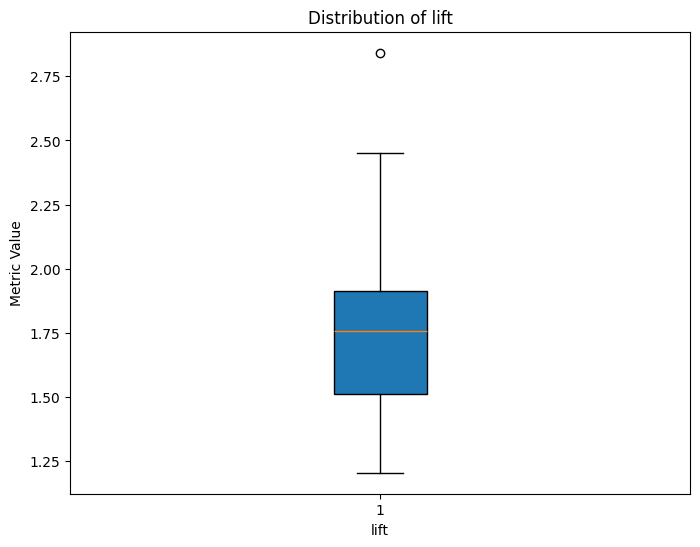

In [101]:
plt.figure(figsize = (8,6))
plt.boxplot(rules["lift"], label = "Lift", patch_artist=True)
plt.title("Distribution of lift")
plt.xlabel("lift")
plt.ylabel("Metric Value")

plt.show()

# **HEATMAP FOR ASSOCIATION RULE METRICS**

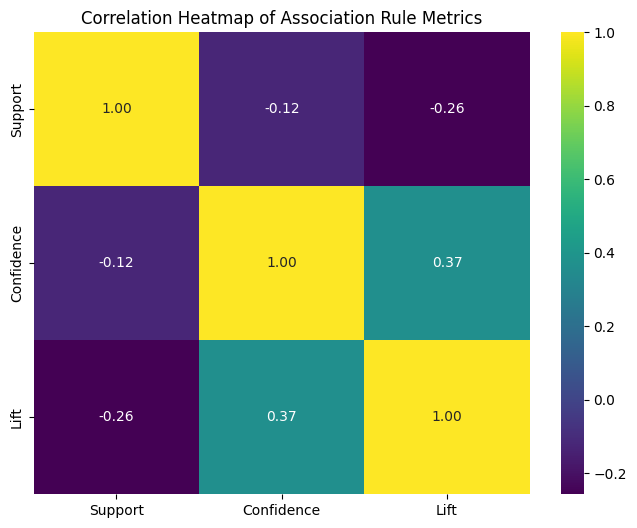

In [106]:
df2 = pd.DataFrame({"Support": rules["support"],"Confidence" : rules["confidence"],"Lift": rules["lift"]})

corr_matrix = df2.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap of Association Rule Metrics")

plt.show()

# **PAIRPLOT FOR ASSOCIATION RULE METRICS**

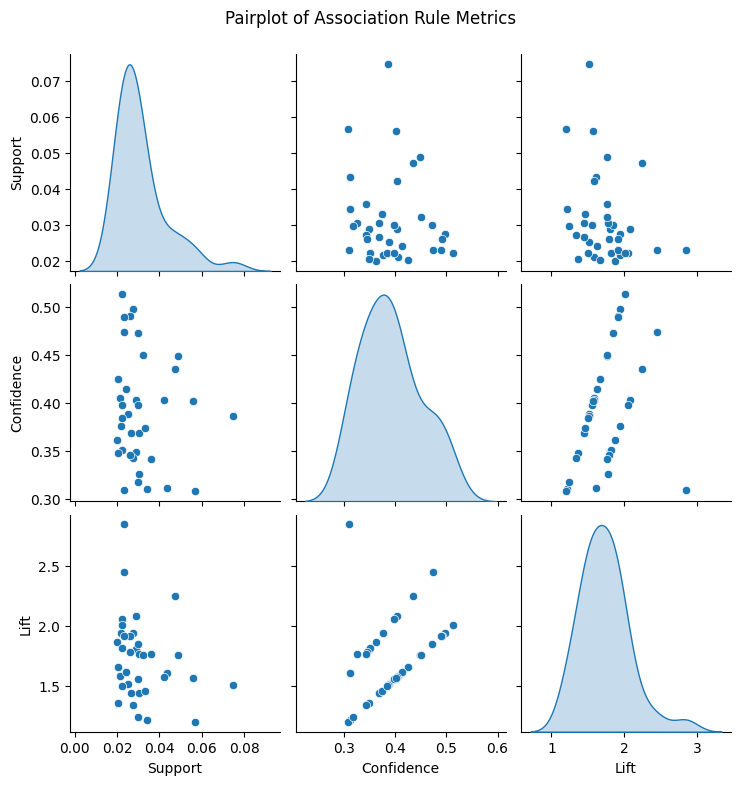

In [121]:
sns.pairplot(df2, diag_kind='kde', palette='Set1')

plt.suptitle("Pairplot of Association Rule Metrics",y = 1.04)
plt.show()

# **HISTOGRAMS FOR ASSOCIATION RULE METRICS**

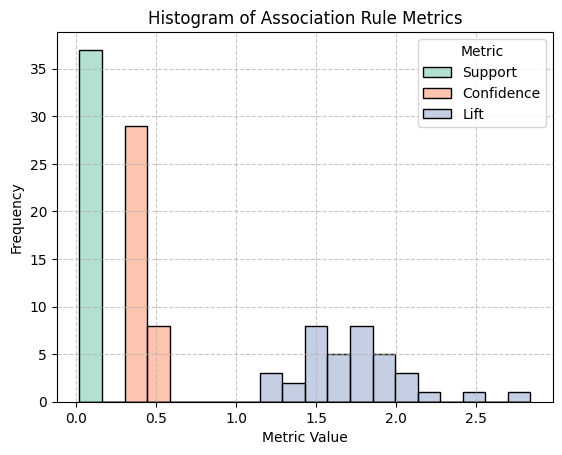

In [130]:
df3 = df2.melt(var_name="Metric", value_name="Value")

sns.histplot(df3, x="Value", hue="Metric",bins = 20, palette="Set2")
plt.title("Histogram of Association Rule Metrics")
plt.xlabel("Metric Value")
plt.ylabel("Frequency")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()